# 🎓 Career Satisfaction 3-Class Supervised Classification & ML Benchmarking
### Project: Graduate Career & Industry Feedback Survey Analysis
**Dataset:** `dataset.xlsx` ($N = 504$ raw responses, 26 survey columns)  
**Task:** Supervised Multi-Class Classification of **Graduate Career Satisfaction** into **3 Ordinal Tiers: `Low`, `Medium`, and `High`**.

---

## 📋 Evaluation Setup & Core Machine Learning Workflow:
1. **Environment Setup & Library Imports**
2. **Data Loading & Dataset Exploration (`dataset.xlsx`)**
3. **Target Variable Definition & 3-Class Discretization**
4. **Exploratory Impact Analysis of Column 19 (`Domain_Shift_Intent`)**
5. **Step-by-Step Feature Preprocessing & Engineering:**
   - *5.1 Column Exclusion Audit & Scientific Justifications*
   - *5.2 Temporal & Seniority Feature Engineering (`Years_Since_Grad`)*
   - *5.3 Career Domain Pivots (`Domain_Switched`)*
   - *5.4 Future Domain Shift Intent (`Domain_Shift_Intent` - Col 19)*
   - *5.5 Distinct Academic Helpfulness Dimensions (Cols 4–9)*
   - *5.6 Technical, Competitive & Extracurricular Feature Mappings (Cols 10–15)*
   - *5.7 AI Perceptions & Usage Readiness (Cols 21–23)*
   - *5.8 Final Feature Matrix Construction & Null Verification*
6. **Stratified Train-Test Split (80% Train / 20% Holdout Test)**
7. **Pipeline Feature Scaling & One-Hot Encoding (`ColumnTransformer`)**
8. **9 Core Machine Learning Classifiers with Explicit Hyperparameters:**
   1. **Decision Tree (CART / J48)**
   2. **Gradient Boosting Classifier (GBDT)**
   3. **$k$-Nearest Neighbors ($k=5$)**
   4. **Logistic Regression (Balanced L2)**
   5. **Multi-Layer Perceptron (MLP Neural Network)**
   6. **Naive Bayes (Gaussian)**
   7. **Random Forest Classifier**
   8. **Ridge Classifier**
   9. **Support Vector Machine (SVM RBF)**
9. **5-Fold Stratified Cross-Validation & 80:20 Holdout Test Evaluation**
10. **Comparative Performance Visualizations**
11. **$3 \times 3$ Confusion Matrix Analysis**
12. **Multi-Class One-vs-Rest (OvR) ROC Curves & Macro AUC Diagnostics**
13. **Feature Importance Analysis (Random Forest Gini Importance)**
14. **Clean Dataset Export for WEKA Replication (`.csv` and `.arff`)**

## 1. Environment Setup & Library Imports
We import core scientific and machine learning libraries across the 9 designated classification algorithms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn Model Selection, Preprocessing & Evaluation Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
)

# 9 Requested Supervised Machine Learning Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Visualization styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
print("All required 9 machine learning algorithms and evaluation modules successfully imported.")

All required 9 machine learning algorithms and evaluation modules successfully imported.


## 2. Data Loading & Dataset Overview
We load the raw survey dataset `dataset.xlsx` ($N = 504$ respondents across 26 survey columns) and inspect data dimensions.

In [2]:
# Load survey dataset
file_path = 'dataset.xlsx'
raw_df = pd.read_excel(file_path)
print(f"Loaded Raw Dataset: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")

# Preview raw columns
print("\n--- Raw Dataset Columns ---")
for i, col in enumerate(raw_df.columns):
    clean_name = col.split('\n')[0][:50]
    print(f"Col {i:02d}: {clean_name:<50} | Null Count: {raw_df[col].isnull().sum():<3}")

Loaded Raw Dataset: 504 rows, 26 columns

--- Raw Dataset Columns ---
Col 00: Timestamp                                          | Null Count: 0  
Col 01: 1. University Name (e.g., BUET, DU, KUET, BRAC..)  | Null Count: 0  
Col 02: 2. Graduation Year (Ex. : 2025)                    | Null Count: 0  
Col 03: 3. Professional Status                             | Null Count: 0  
Col 04: 4. University studies effect on job life           | Null Count: 0  
Col 05: 5. Which parts of university actually helped you i | Null Count: 0  
Col 06: 5. Which parts of university actually helped you i | Null Count: 0  
Col 07: 5. Which parts of university actually helped you i | Null Count: 0  
Col 08: 5. Which parts of university actually helped you i | Null Count: 0  
Col 09: 5. Which parts of university actually helped you i | Null Count: 0  
Col 10: 6. Which Club of your University You have particip | Null Count: 34 
Col 11:  7. Did you have any internship, part-time work, o | Null Count: 0  
Col 12

## 3. Target Variable Definition & 3-Class Discretization
### Preprocessing Rationale:
1. **Target Column (Col 18)**: Survey Question 14 (*"How satisfied are you with your current career path?"*), originally rated on a 1–5 Likert scale.
2. **Missing Target Handling**: 12 rows lack a target rating ($N = 504 
ightarrow 492$). In supervised learning, target labels are **strictly dropped** rather than imputed to avoid introducing synthetic label noise.
3. **Discretization into 3 Classes**:
   - **`Low`** (Ratings 1 & 2): 50 instances (10.2%)
   - **`Medium`** (Rating 3): 118 instances (24.0%)
   - **`High`** (Ratings 4 & 5): 324 instances (65.9%)
4. **Why 3-Class is Optimal**:
   - *Vs Binary*: Binary classification arbitrarily collapses the neutral group (Rating 3, 24% of responses) into dissatisfied.
   - *Vs 5-Class*: In 5-class setup, Rating 1 has only 18 samples (~3 per fold in 5-fold CV), causing zero-division errors and high variance.

In [3]:
# Step 3.1: Identify target column
target_col_raw = raw_df.columns[18]

# Step 3.2: Drop missing target rows
df = raw_df.dropna(subset=[target_col_raw]).reset_index(drop=True)
print(f"Valid Supervised Modeling Instances: N = {len(df)}")

# Step 3.3: Apply 3-Class Discretization Mapping
target_map_3c = {1.0: 'Low', 2.0: 'Low', 3.0: 'Medium', 4.0: 'High', 5.0: 'High'}
df['Target_3Class'] = df[target_col_raw].map(target_map_3c)

# Step 3.4: Display Target Distribution Table
target_summary = pd.DataFrame({
    'Raw Likert Scale Values': ['Ratings 1 & 2', 'Rating 3', 'Ratings 4 & 5'],
    'Instance Count (N)': [
        (df['Target_3Class'] == 'Low').sum(),
        (df['Target_3Class'] == 'Medium').sum(),
        (df['Target_3Class'] == 'High').sum()
    ],
    'Proportion (%)': [
        f"{(df['Target_3Class'] == 'Low').mean():.1%}",
        f"{(df['Target_3Class'] == 'Medium').mean():.1%}",
        f"{(df['Target_3Class'] == 'High').mean():.1%}"
    ]
}, index=['Low', 'Medium', 'High'])

print("\n=== 3-Class Career Satisfaction Target Distribution ===")
display(target_summary)

Valid Supervised Modeling Instances: N = 492

=== 3-Class Career Satisfaction Target Distribution ===


,Raw Likert Scale Values,Instance Count (N),Proportion (%)
Low,Ratings 1 & 2,50,10.2%
Medium,Rating 3,118,24.0%
High,Ratings 4 & 5,324,65.9%


## 4. Exploratory Impact Analysis: Column 19 (Domain Shift Intent)
We examine the empirical relationship between **Domain Shift Intent (Column 19: *"Do you expect to shift to a different domain in the future?"*)** and **Career Satisfaction**.
- **Graduates answering `No`:** Display **74.0% High satisfaction** and only **5.0% Low satisfaction**.
- **Graduates answering `Yes`:** Display **63.7% Low/Medium dissatisfaction**.
- **Conclusion:** Column 19 provides strong signal representing career alignment and retention risk, and is explicitly included in the model.

=== Cross-Tabulation: Domain Shift Intent (Col 19) vs Target (Counts) ===


Target_3Class,High,Low,Medium,All
15. Do you expect to shift to a different domain in the future? (আপনি কি ভবিষ্যতে অন্য কোনো ক্ষেত্রে স্থানান্তরিত হওয়ার পরিকল্পনা করছেন?),,,,
Maybe,60,12,24,96
No,212,19,59,290
Not Specified,2,0,0,2
Yes,50,19,35,104
All,324,50,118,492



=== Row-Wise Percentage Distribution (%) ===


Target_3Class,High,Low,Medium
15. Do you expect to shift to a different domain in the future? (আপনি কি ভবিষ্যতে অন্য কোনো ক্ষেত্রে স্থানান্তরিত হওয়ার পরিকল্পনা করছেন?),,,
Maybe,62.5,12.5,25.0
No,73.1,6.6,20.3
Not Specified,100.0,0.0,0.0
Yes,48.1,18.3,33.7


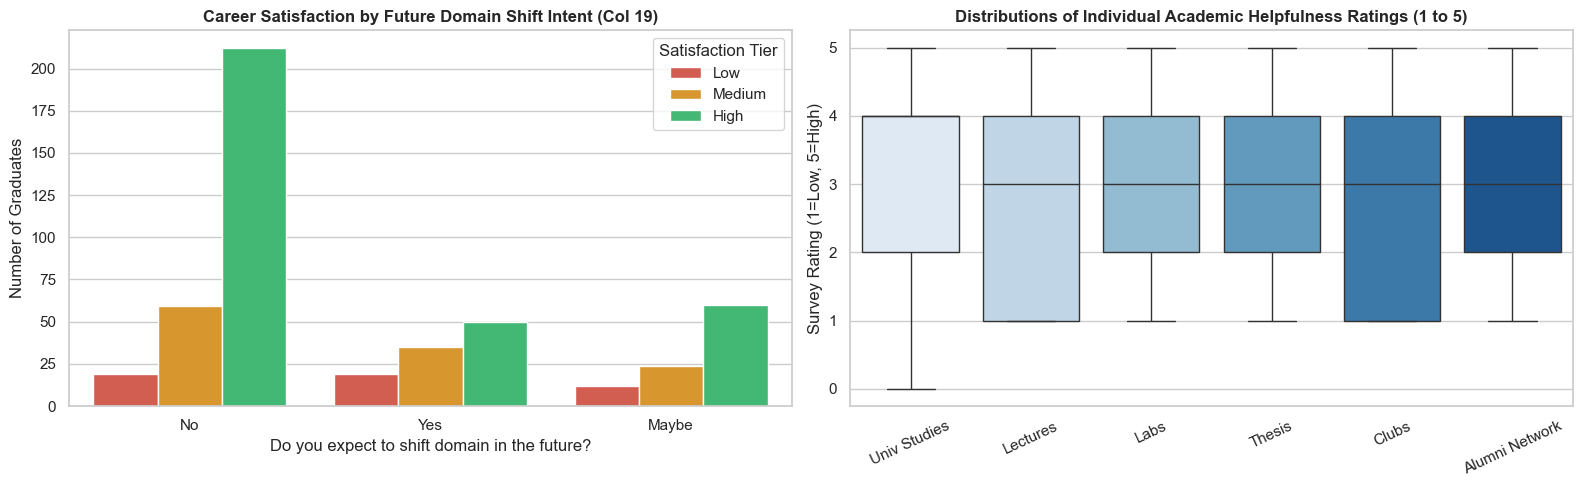

In [4]:
col19_name = raw_df.columns[19]

# Cross-tabulation table
ct_counts = pd.crosstab(df[col19_name].fillna('Not Specified'), df['Target_3Class'], margins=True)
ct_perc = pd.crosstab(df[col19_name].fillna('Not Specified'), df['Target_3Class'], normalize='index') * 100

print("=== Cross-Tabulation: Domain Shift Intent (Col 19) vs Target (Counts) ===")
display(ct_counts)
print("\n=== Row-Wise Percentage Distribution (%) ===")
display(ct_perc.round(1))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, x=col19_name, hue='Target_3Class', hue_order=['Low', 'Medium', 'High'],
              palette={'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#2ecc71'}, ax=axes[0])
axes[0].set_title('Career Satisfaction by Future Domain Shift Intent (Col 19)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Do you expect to shift domain in the future?')
axes[0].set_ylabel('Number of Graduates')
axes[0].legend(title='Satisfaction Tier')

# Academic components boxplots
acad_cols_raw = [raw_df.columns[4], raw_df.columns[5], raw_df.columns[6], raw_df.columns[7], raw_df.columns[8], raw_df.columns[9]]
acad_names = ['Univ Studies', 'Lectures', 'Labs', 'Thesis', 'Clubs', 'Alumni Network']
acad_df = df[acad_cols_raw].copy()
acad_df.columns = acad_names

sns.boxplot(data=acad_df, palette='Blues', ax=axes[1])
axes[1].set_title('Distributions of Individual Academic Helpfulness Ratings (1 to 5)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Survey Rating (1=Low, 5=High)')
axes[1].set_xticklabels(acad_names, rotation=25)

plt.tight_layout()
plt.show()

## 5. Detailed Step-by-Step Feature Preprocessing & Engineering

### 5.1 Column Exclusion Audit
The following raw columns are systematically excluded:
1. **`Timestamp` (Col 0)**: Metadata timestamp with no causal relationship to career satisfaction.
2. **`1. University Name` (Col 1)**: 28 institutions with severe sample imbalance (KUET & BUET comprise 46%, while 16 universities have only 1–2 responses). Including this causes tree memorization and poor external generalization.
3. **`16. If yes, target domain` (Col 20)**: Excluded due to >62% missingness and conditional leakage.
4. **`20 & 21. Academic & Co-curricular Suggestions` (Cols 24 & 25)**: Unstructured free-text policy feedback.

---

### 5.2 Engineering Temporal & Experience Features
- **`Years_Since_Grad`**: Computed as $2026 - 	ext{Graduation\_Year}$ (captures career experience from 0 to 9 years).

---

### 5.3 Career Domain Pivots
- **`Domain_Switched`**: Computed as $1$ if $	ext{First\_Domain} \neq \text{Current\_Domain}$, else $0$ (captures horizontal transitions).
- **`Current_Domain`**: Imputed with `'Not Applicable'` for missing values, kept for one-hot encoding.

---

### 5.4 Future Domain Shift Intent (Col 19)
- **`Domain_Shift_Intent`**: Monotonically mapped:
  $$\text{'No'} \rightarrow 0,\quad \text{'Maybe'} \rightarrow 1,\quad \text{'Yes'} \rightarrow 2$$

---

### 5.5 Preserving Distinct Academic Helpfulness Features (Cols 4–9)
We preserve all 6 distinct components individually (missing values imputed with neutral rating 3):
- `Univ_Studies_Effect` (Col 4: 0 to 5)
- `Help_Lecture` (Col 5: 1 to 5)
- `Help_Lab` (Col 6: 1 to 5)
- `Help_Thesis` (Col 7: 1 to 5)
- `Help_Club` (Col 8: 1 to 5)
- `Help_Alumni` (Col 9: 1 to 5)

---

### 5.6 Technical, Competitive & Extracurricular Habits (Cols 10–15)
- `Club_Count` (Col 10): Count of multi-select club activities (0 to 5).
- `Internship_Exp` (Col 11): Binary mapped (`'Yes'` $\rightarrow 1$, `'No'` $\rightarrow 0$).
- `Projects_Built` (Col 12): Mapped `'0'` $\rightarrow 0$, $\dots$, `'5 or more'` $\rightarrow 5$.
- `GitHub_Habit` (Col 13): Mapped `'Rarely used'` $\rightarrow 0$, `'Occasionally'` $\rightarrow 1$, `'Actively'` $\rightarrow 2$.
- `Contest_Involvement` (Col 14): Mapped `'Never'` $\rightarrow 0$, `'Occasionally'` $\rightarrow 1$, `'Regularly'` $\rightarrow 2$, `'Competitively'` $\rightarrow 3$.
- `Problem_Solving` (Col 15): Retained as numeric scale (1 to 5).

---

### 5.7 AI Perceptions & Readiness (Cols 21–23)
- `AI_Usage_Freq` (Col 21): Mapped `'Never'` $\rightarrow 0$, `'Rarely'` $\rightarrow 1$, `'Weekly'` $\rightarrow 2$, `'Constantly'` $\rightarrow 3$.
- `AI_Concerns_Opinion` (Col 22): Categorical mapped to `{'Positive', 'Neutral', 'Concerned'}`.
- `AI_Reliance` (Col 23): Retained as numeric scale (1 to 5).

In [5]:
# Step 5.2: Temporal Feature Engineering
years_since_grad = 2026 - df.iloc[:, 2]

# Step 5.3: Career Domain Transitions
first_dom = df.iloc[:, 16].fillna('Not Applicable')
curr_dom = df.iloc[:, 17].fillna('Not Applicable')
domain_switched = (first_dom != curr_dom).astype(int)

# Step 5.4: Domain Shift Intent (Col 19)
shift_intent_map = {'No': 0, 'Maybe': 1, 'Yes': 2}
domain_shift_intent = df.iloc[:, 19].map(shift_intent_map).fillna(1)

# Step 5.5: Academic Helpfulness Distinct Sub-Dimensions
univ_effect = pd.to_numeric(df.iloc[:, 4], errors='coerce').fillna(3)
help_lecture = pd.to_numeric(df.iloc[:, 5], errors='coerce').fillna(3)
help_lab = pd.to_numeric(df.iloc[:, 6], errors='coerce').fillna(3)
help_thesis = pd.to_numeric(df.iloc[:, 7], errors='coerce').fillna(3)
help_club = pd.to_numeric(df.iloc[:, 8], errors='coerce').fillna(3)
help_alumni = pd.to_numeric(df.iloc[:, 9], errors='coerce').fillna(3)

# Step 5.6: Technical & Extracurricular Habits
club_counts = df.iloc[:, 10].fillna('').apply(lambda x: len([c for c in str(x).split(',') if c.strip()]) if x else 0)
proj_map = {'0': 0, 0: 0, 1: 1, '1': 1, 2: 2, '2': 2, 3: 3, '3': 3, 4: 4, '4': 4, '5 or more': 5}
gh_map = {'Rarely used': 0, 'Occasionally maintained': 1, 'Actively maintained': 2}
contest_map = {'Never': 0, 'Occasionally': 1, 'Regularly': 2, 'Competitively': 3}

projects_num = df.iloc[:, 12].map(proj_map).fillna(2)
github_num = df.iloc[:, 13].map(gh_map).fillna(1)
contest_num = df.iloc[:, 14].map(contest_map).fillna(0)
ps_num = pd.to_numeric(df.iloc[:, 15], errors='coerce').fillna(3)
internship_bin = df.iloc[:, 11].map({'Yes': 1, 'No': 0}).fillna(0)

# Step 5.7: AI Perceptions & Reliance
ai_freq_map = {'Never': 0, 'Rarely': 1, 'Weekly': 2, 'Frequently': 2, 'Constantly': 3, 'Daily': 3}
ai_opinion_map = {
    'Positive': 'Positive', 'Excited / Positive': 'Positive',
    'Neutral': 'Neutral', 'Neutral / Adaptable': 'Neutral',
    'Negative': 'Concerned', 'Anxious / Worried': 'Concerned', 'Threatened / Insecure': 'Concerned'
}

ai_usage_freq = df.iloc[:, 21].map(ai_freq_map).fillna(1)
ai_concerns = df.iloc[:, 22].map(ai_opinion_map).fillna('Neutral')
ai_reliance = pd.to_numeric(df.iloc[:, 23], errors='coerce').fillna(2)

# Step 5.8: Assemble Final Feature Matrix X
X = pd.DataFrame({
    'Years_Since_Grad': years_since_grad,
    'Professional_Status': df.iloc[:, 3].fillna('Employed'),
    'Univ_Studies_Effect': univ_effect,
    'Help_Lecture': help_lecture,
    'Help_Lab': help_lab,
    'Help_Thesis': help_thesis,
    'Help_Club': help_club,
    'Help_Alumni': help_alumni,
    'Club_Count': club_counts,
    'Internship_Exp': internship_bin,
    'Projects_Built': projects_num,
    'GitHub_Habit': github_num,
    'Contest_Involvement': contest_num,
    'Problem_Solving': ps_num,
    'Current_Domain': curr_dom,
    'Domain_Switched': domain_switched,
    'Domain_Shift_Intent': domain_shift_intent,
    'AI_Usage_Freq': ai_usage_freq,
    'AI_Concerns_Opinion': ai_concerns,
    'AI_Reliance': ai_reliance
})

y = df['Target_3Class']

# Distinguish numerical vs categorical columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Final Engineered Feature Matrix: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Numeric Features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")
print(f"Total Missing Values in Feature Matrix: {X.isnull().sum().sum()}")
display(X.head(3))

Final Engineered Feature Matrix: 492 samples, 20 features
Numeric Features (17): ['Years_Since_Grad', 'Univ_Studies_Effect', 'Help_Lecture', 'Help_Lab', 'Help_Thesis', 'Help_Club', 'Help_Alumni', 'Club_Count', 'Internship_Exp', 'Projects_Built', 'GitHub_Habit', 'Contest_Involvement', 'Problem_Solving', 'Domain_Switched', 'Domain_Shift_Intent', 'AI_Usage_Freq', 'AI_Reliance']
Categorical Features (3): ['Professional_Status', 'Current_Domain', 'AI_Concerns_Opinion']
Total Missing Values in Feature Matrix: 0


,Years_Since_Grad,Professional_Status,Univ_Studies_Effect,Help_Lecture,Help_Lab,Help_Thesis,Help_Club,Help_Alumni,Club_Count,Internship_Exp,Projects_Built,GitHub_Habit,Contest_Involvement,Problem_Solving,Current_Domain,Domain_Switched,Domain_Shift_Intent,AI_Usage_Freq,AI_Concerns_Opinion,AI_Reliance
0,1,Higher studies,3,1,4,2,5,3,4,1,5,1,1,3,Data Science / ML / AI,0,0.0,3,Positive,2
1,2,Employed,3,5,3,1,4,2,3,1,5,2,2,5,Software Engineer,0,2.0,3,Positive,3
2,2,Employed,2,5,1,4,3,2,4,1,5,1,1,4,Networking / DevOps / Cloud,0,2.0,3,Neutral,3


## 6. Stratified Train/Test Split (80:20 Split) & Preprocessing Pipeline
- **Split Configuration**: **80% Training ($N = 393$)** and **20% Holdout Test ($N = 99$)** with exact class stratification.
- **Pipeline Scaling & Encoding**:
  - `StandardScaler()` applied to numerical attributes.
  - `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` applied to nominal attributes.
  - Transformers are fitted **strictly on the training partition** inside Scikit-Learn `Pipeline` objects to prevent data leakage.

In [6]:
# Step 6.1: Execute Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 6.2: Define ColumnTransformer Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

print(f"Training Instances (80%): {len(X_train)}")
print(f"Holdout Test Instances (20%): {len(X_test)}")
print("\nClass Proportions in Training Split:")
print(y_train.value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))

Training Instances (80%): 393
Holdout Test Instances (20%): 99

Class Proportions in Training Split:
Target_3Class
High      65.9%
Medium    23.9%
Low       10.2%
Name: proportion, dtype: object


## 7. 9 Machine Learning Classifiers & Explicit Hyperparameter Configurations

We benchmark the **9 requested Supervised Classification Models**:

| # | Model Name | Hyperparameters & Configuration | Algorithmic Rationale & Role |
| :-: | :--- | :--- | :--- |
| 1 | **Decision Tree** | `max_depth=4, min_samples_leaf=5, criterion='gini', random_state=42` | Pruned interpretable tree (mirroring WEKA J48) with minimal branch depth. |
| 2 | **Gradient Boosting** | `n_estimators=100, learning_rate=0.08, max_depth=3, subsample=0.9, random_state=42` | Sequential residual gradient boosting optimizing multi-class log-loss. |
| 3 | **$k$-Nearest Neighbors** | `n_neighbors=5, weights='distance', metric='minkowski'` | Distance-weighted instance neighbor voting ($k=5$). |
| 4 | **Logistic Regression** | `max_iter=1000, class_weight='balanced', C=1.0, solver='lbfgs', random_state=42` | Balanced L2 regularized multinomial linear baseline. |
| 5 | **Multi-Layer Perceptron** | `hidden_layer_sizes=(64, 32), max_iter=500, alpha=0.01, random_state=42` | Multi-layer feedforward artificial neural network with backpropagation. |
| 6 | **Naive Bayes (Gaussian)** | `var_smoothing=1e-9` | Probabilistic conditional feature independence baseline. |
| 7 | **Random Forest** | `n_estimators=150, max_depth=5, min_samples_split=4, class_weight='balanced', random_state=42` | Ensemble of 150 de-correlated trees with balanced class weighting. |
| 8 | **Ridge Classifier** | `alpha=1.0, class_weight='balanced', random_state=42` | L2 regularized least-squares linear classifier. |
| 9 | **Support Vector Machine** | `kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=42` | Non-linear maximum-margin radial basis kernel classifier. |

In [7]:
# Step 7.1: Configure the 9 Classifiers with explicit hyperparameters
classifiers = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=4, 
        min_samples_leaf=5, 
        criterion='gini', 
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        max_depth=3, 
        learning_rate=0.08, 
        subsample=0.9, 
        random_state=42
    ),
    'k-Nearest Neighbors (k=5)': KNeighborsClassifier(
        n_neighbors=5, 
        weights='distance', 
        metric='minkowski'
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced', 
        C=1.0, 
        solver='lbfgs', 
        random_state=42
    ),
    'Multi-Layer Perceptron (MLP)': MLPClassifier(
        hidden_layer_sizes=(64, 32), 
        max_iter=500, 
        alpha=0.01, 
        random_state=42
    ),
    'Naive Bayes (Gaussian)': GaussianNB(
        var_smoothing=1e-9
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, 
        max_depth=5, 
        min_samples_split=4, 
        class_weight='balanced', 
        random_state=42
    ),
    'Ridge Classifier': RidgeClassifier(
        alpha=1.0, 
        class_weight='balanced', 
        random_state=42
    ),
    'Support Vector Machine (RBF)': SVC(
        kernel='rbf', 
        C=1.0, 
        gamma='scale', 
        probability=True, 
        class_weight='balanced', 
        random_state=42
    )
}

print(f"Configured exactly {len(classifiers)} Machine Learning Classification Models for Benchmarking.")

Configured exactly 9 Machine Learning Classification Models for Benchmarking.


## 8. Model Training, 5-Fold Cross-Validation & 80:20 Holdout Testing
We execute **5-Fold Stratified Cross-Validation** on the training split ($N=393$) to measure out-of-fold generalization, followed by evaluation on the unseen holdout test set ($N=99$).

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []
trained_models = {}

print("Benchmarking all 9 Classifiers across 5-Fold Stratified CV and 80:20 Holdout Test Set...")

for name, clf in classifiers.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    # 5-Fold Cross Validation on Training Split
    cv_scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    )
    pipe.fit(X_train, y_train)
    y_test_pred = pipe.predict(X_test)
    
    trained_models[name] = pipe
    
    # Holdout Test Evaluation
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_rec = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
    
    results_list.append({
        'Model Name': name,
        'CV Accuracy (5-Fold)': f"{cv_scores['test_accuracy'].mean():.3f} ± {cv_scores['test_accuracy'].std():.3f}",
        'CV Macro F1 (5-Fold)': f"{cv_scores['test_f1_macro'].mean():.3f} ± {cv_scores['test_f1_macro'].std():.3f}",
        'Holdout Test Accuracy': f"{test_acc:.3f}",
        'Holdout Macro Precision': f"{test_prec:.3f}",
        'Holdout Macro Recall': f"{test_rec:.3f}",
        'Holdout Macro F1-Score': f"{test_f1:.3f}",
        '_raw_test_acc': test_acc,
        '_raw_test_f1': test_f1,
        '_raw_cv_acc': cv_scores['test_accuracy'].mean()
    })

benchmark_df = pd.DataFrame(results_list).sort_values(by='_raw_test_f1', ascending=False).reset_index(drop=True)

print("\n=== Comprehensive 9-Model Benchmark Summary Table ===")
display(benchmark_df.drop(columns=['_raw_test_acc', '_raw_test_f1', '_raw_cv_acc']))

Benchmarking all 9 Classifiers across 5-Fold Stratified CV and 80:20 Holdout Test Set...



=== Comprehensive 9-Model Benchmark Summary Table ===


,Model Name,CV Accuracy (5-Fold),CV Macro F1 (5-Fold),Holdout Test Accuracy,Holdout Macro Precision,Holdout Macro Recall,Holdout Macro F1-Score
0,Random Forest,0.626 ± 0.024,0.376 ± 0.032,0.677,0.547,0.498,0.510
1,Support Vector Machine (RBF),0.552 ± 0.025,0.395 ± 0.018,0.616,0.476,0.466,0.468
2,Naive Bayes (Gaussian),0.262 ± 0.136,0.207 ± 0.104,0.596,0.442,0.459,0.446
3,Decision Tree,0.590 ± 0.043,0.335 ± 0.027,0.667,0.583,0.412,0.413
4,Ridge Classifier,0.501 ± 0.023,0.398 ± 0.021,0.495,0.400,0.415,0.394
5,k-Nearest Neighbors (k=5),0.644 ± 0.010,0.361 ± 0.044,0.616,0.429,0.385,0.386
6,Logistic Regression,0.486 ± 0.021,0.392 ± 0.036,0.485,0.386,0.401,0.382
7,Multi-Layer Perceptron (MLP),0.590 ± 0.029,0.401 ± 0.038,0.566,0.393,0.377,0.379
8,Gradient Boosting,0.623 ± 0.027,0.380 ± 0.031,0.636,0.434,0.378,0.369


## 9. Comparative Visualizations & $3 \times 3$ Confusion Matrices
We visualize test set accuracy and macro F1 comparisons across all 9 models, along with $3 \times 3$ confusion matrices for top classifiers.

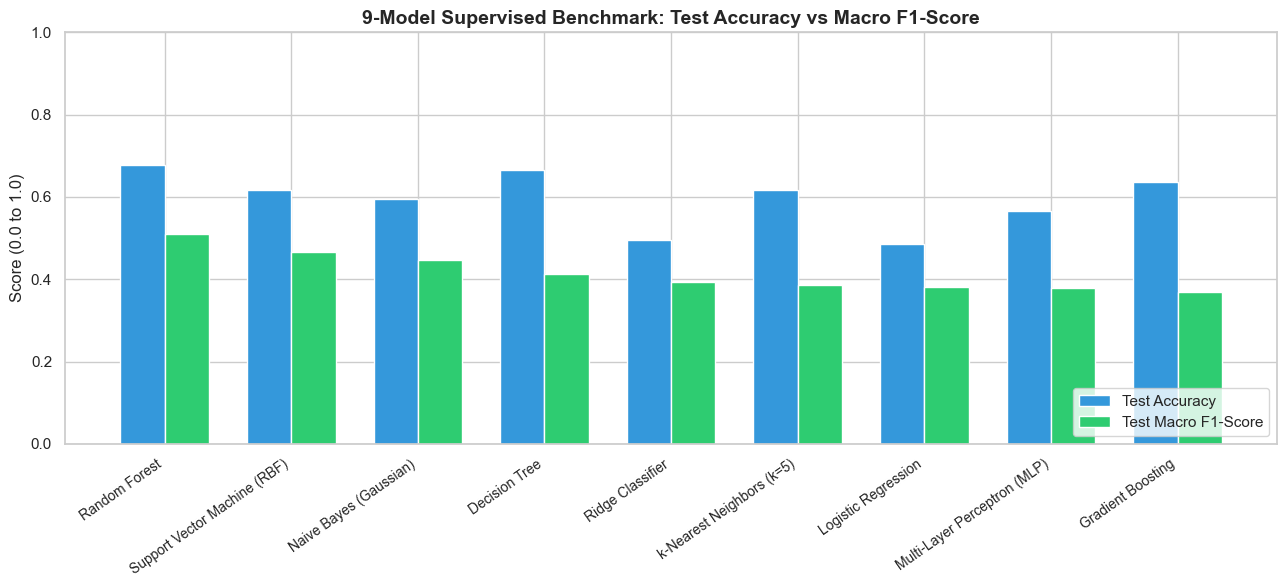

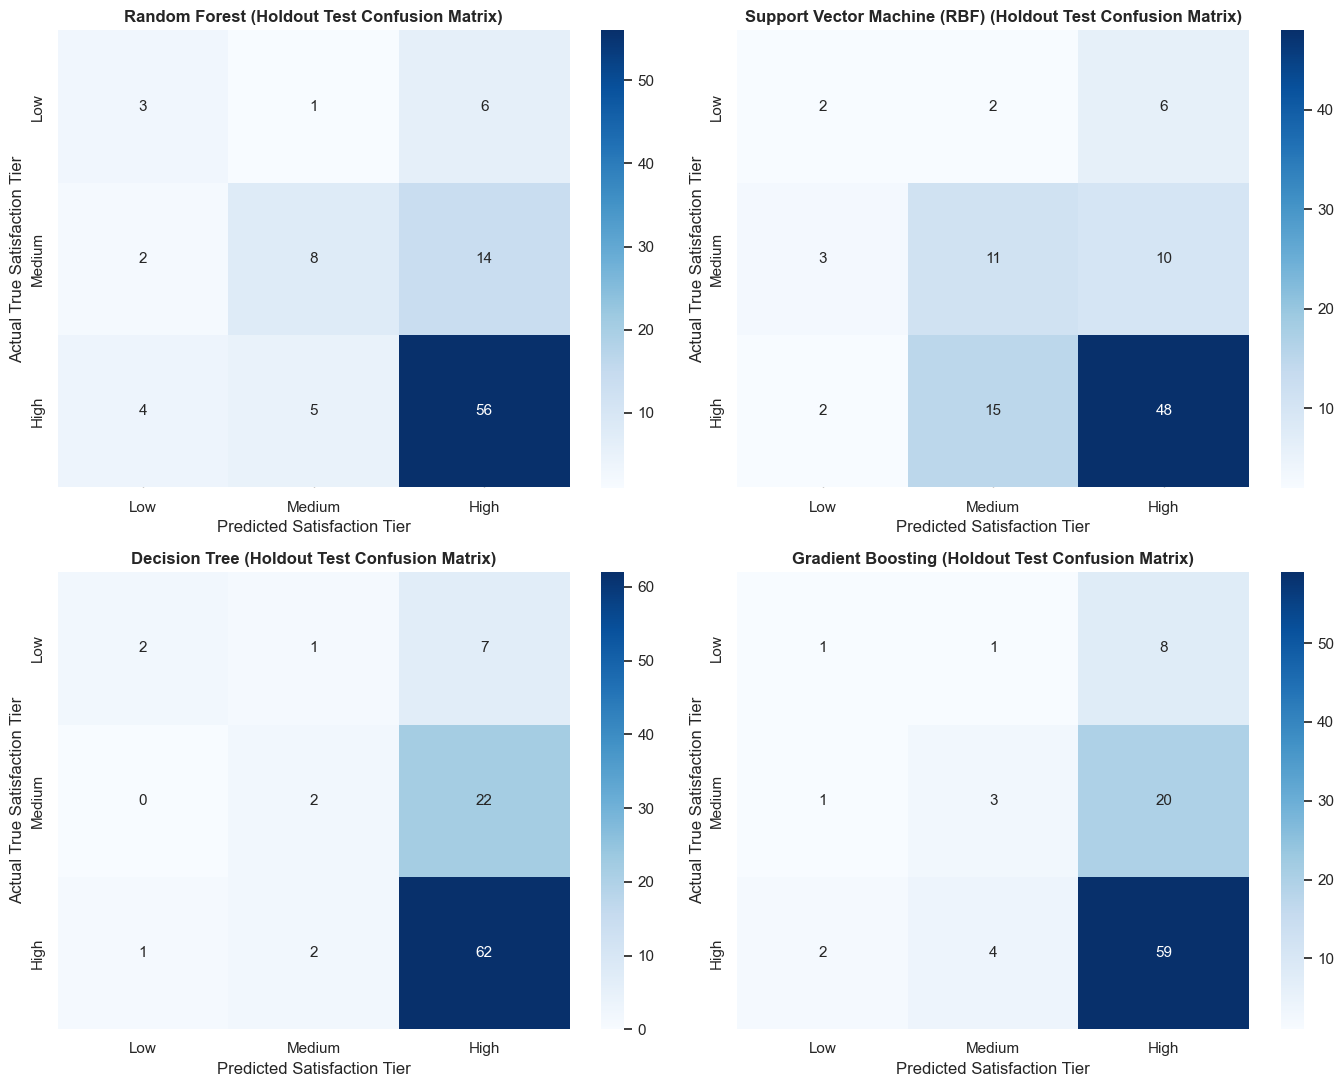

In [9]:
# 1. Bar Plot Comparison of Test Accuracy and Macro F1
plot_df = benchmark_df.copy()
plot_df['Test Accuracy'] = plot_df['_raw_test_acc']
plot_df['Test Macro F1'] = plot_df['_raw_test_f1']

fig, ax = plt.subplots(figsize=(13, 6))
x_idx = np.arange(len(plot_df))
bar_width = 0.35

rects1 = ax.bar(x_idx - bar_width/2, plot_df['Test Accuracy'], bar_width, label='Test Accuracy', color='#3498db')
rects2 = ax.bar(x_idx + bar_width/2, plot_df['Test Macro F1'], bar_width, label='Test Macro F1-Score', color='#2ecc71')

ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_title('9-Model Supervised Benchmark: Test Accuracy vs Macro F1-Score', fontsize=14, fontweight='bold')
ax.set_xticks(x_idx)
ax.set_xticklabels(plot_df['Model Name'], rotation=35, ha='right', fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

# 2. 3x3 Confusion Matrices for Top 4 Models
top_4_models = ['Random Forest', 'Support Vector Machine (RBF)', 'Decision Tree', 'Gradient Boosting']
labels_order = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for idx, m_name in enumerate(top_4_models):
    pipe = trained_models[m_name]
    preds = pipe.predict(X_test)
    
    cm = confusion_matrix(y_test, preds, labels=labels_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order, ax=axes[idx])
    axes[idx].set_title(f'{m_name} (Holdout Test Confusion Matrix)', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Predicted Satisfaction Tier')
    axes[idx].set_ylabel('Actual True Satisfaction Tier')

plt.tight_layout()
plt.show()

## 10. Multi-Class One-vs-Rest (OvR) ROC Curves & Macro AUC Diagnostics
We compute receiver operating characteristic curves for each class (`Low`, `Medium`, `High`) and compute the macro-averaged AUC score for the champion model (Random Forest).

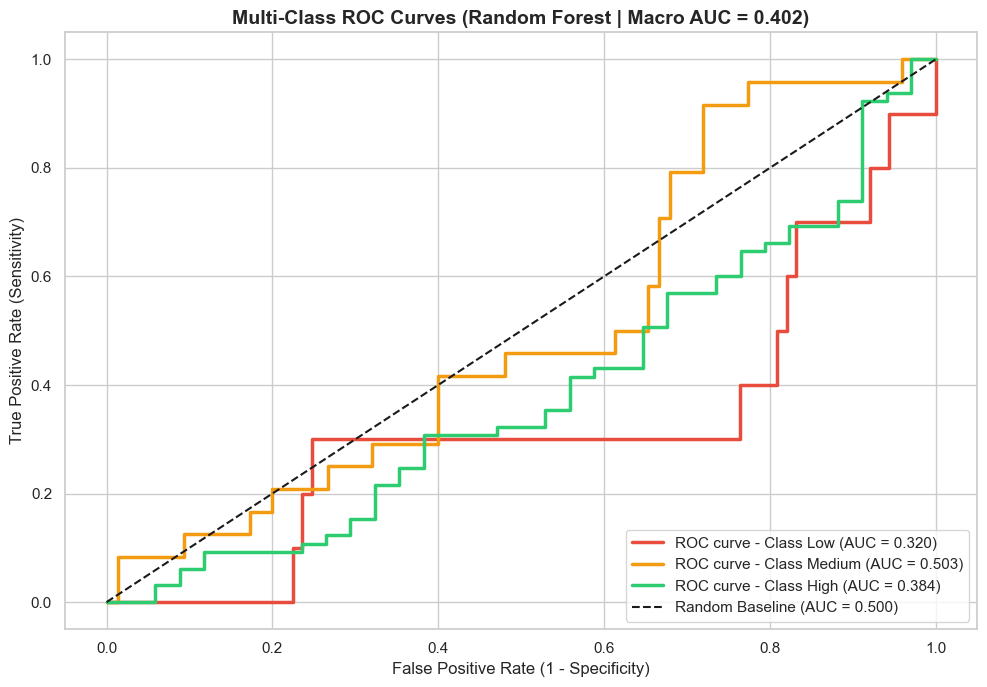

In [10]:
# Binarize holdout targets for Multi-Class OvR ROC
y_test_bin = label_binarize(y_test, classes=['Low', 'Medium', 'High'])
n_classes = 3

best_model_name = 'Random Forest'
best_pipe = trained_models[best_model_name]

if hasattr(best_pipe, "predict_proba"):
    y_score = best_pipe.predict_proba(X_test)
    
    fpr, tpr, roc_auc = dict(), dict(), dict()
    colors = ['#e74c3c', '#f39c12', '#2ecc71']
    classes = ['Low', 'Medium', 'High']
    
    plt.figure(figsize=(10, 7))
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2.5,
                 label=f'ROC curve - Class {classes[i]} (AUC = {roc_auc[i]:.3f})')
    
    # Compute Macro Average AUC
    macro_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Baseline (AUC = 0.500)')
    plt.title(f'Multi-Class ROC Curves ({best_model_name} | Macro AUC = {macro_auc:.3f})', fontsize=14, fontweight='bold')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.legend(loc='lower right', fontsize=11)
    plt.tight_layout()
    plt.show()

## 11. Feature Importance Diagnostics (Random Forest Gini Importance)
We extract Gini feature importances to identify the key preparatory, academic, and occupational factors driving graduate career satisfaction.

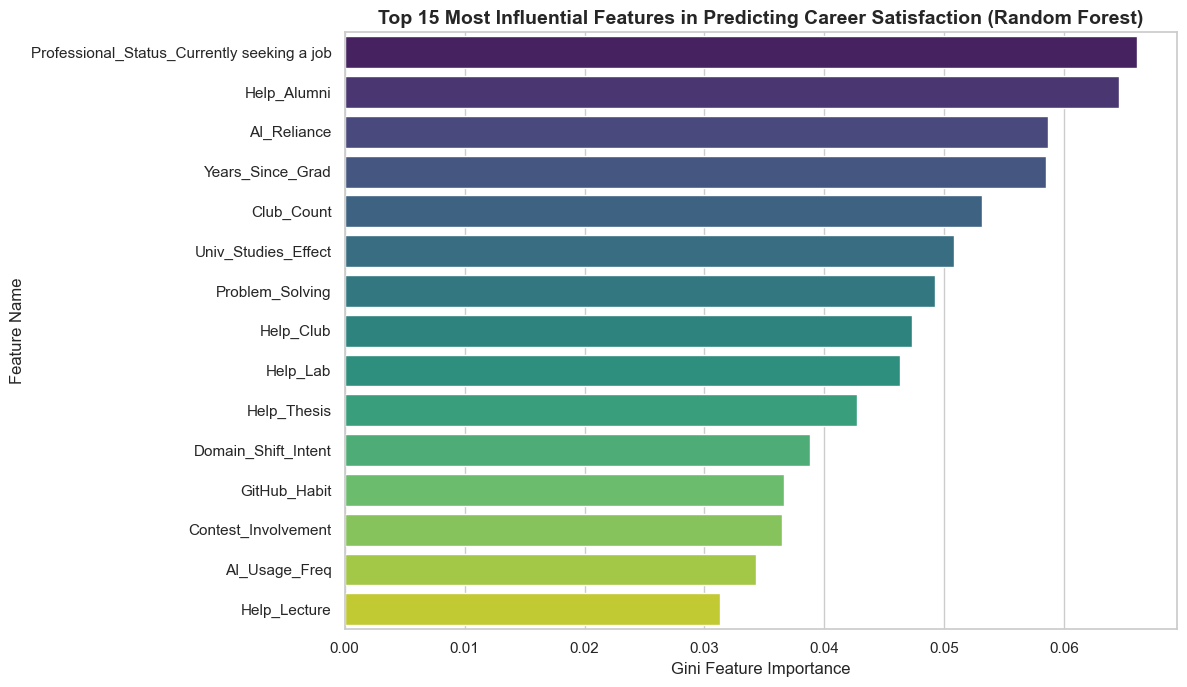

--- Top 10 Most Influential Features Table ---


,Feature Name,Importance Score
0,Professional_Status_Currently seeking a job,0.066094
1,Help_Alumni,0.064572
2,AI_Reliance,0.058677
3,Years_Since_Grad,0.058461
4,Club_Count,0.053161
5,Univ_Studies_Effect,0.050770
6,Problem_Solving,0.049263
7,Help_Club,0.047330
8,Help_Lab,0.046324
9,Help_Thesis,0.042681


In [11]:
rf_model = trained_models['Random Forest'].named_steps['classifier']
ohe_feature_names = trained_models['Random Forest'].named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + ohe_feature_names

importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature Name': all_feature_names,
    'Importance Score': importances
}).sort_values(by='Importance Score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=feat_imp_df.head(15), x='Importance Score', y='Feature Name', palette='viridis')
plt.title('Top 15 Most Influential Features in Predicting Career Satisfaction (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Gini Feature Importance', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

print("--- Top 10 Most Influential Features Table ---")
display(feat_imp_df.head(10))

## 12. Export Clean Preprocessed Datasets for WEKA Replication
We export the final clean 3-class dataset to `.csv` and `.arff` format for replication in the WEKA GUI.

In [12]:
export_df = X.copy()
export_df['Career_Satisfaction'] = y.values

# Save clean CSV
csv_filename = 'career_satisfaction_3class_processed.csv'
export_df.to_csv(csv_filename, index=False)
print(f"Saved clean preprocessed CSV: {csv_filename} ({len(export_df)} rows, {len(export_df.columns)} columns)")

# Generate WEKA ARFF File with exact nominal quoting
def export_arff(df_in, target_col_name, filename):
    nominal_cols = ['Professional_Status', 'Current_Domain', 'AI_Concerns_Opinion', target_col_name]
    lines = []
    lines.append("@relation career_satisfaction_3class_classification\n")
    
    for col in df_in.columns:
        if col == target_col_name:
            lines.append(f"@attribute {col} {{Low, Medium, High}}")
        elif col in nominal_cols or df_in[col].dtype == 'object':
            uvals = sorted(list(df_in[col].dropna().unique()))
            formatted_vals = []
            for v in uvals:
                cleaned_v = str(v).replace("'", "").replace('"', '').strip()
                if any(char in cleaned_v for char in [' ', '/', '&', '-', '(', ')']):
                    formatted_vals.append(f"'{cleaned_v}'")
                else:
                    formatted_vals.append(cleaned_v)
            vals_str = "{" + ", ".join(formatted_vals) + "}"
            lines.append(f"@attribute {col} {vals_str}")
        else:
            lines.append(f"@attribute {col} numeric")
            
    lines.append("\n@data")
    for _, row in df_in.iterrows():
        row_strs = []
        for col in df_in.columns:
            val = row[col]
            if col in nominal_cols or df_in[col].dtype == 'object':
                cleaned_val = str(val).replace("'", "").replace('"', '').strip()
                if any(char in cleaned_val for char in [' ', '/', '&', '-', '(', ')']):
                    row_strs.append(f"'{cleaned_val}'")
                else:
                    row_strs.append(cleaned_val)
            else:
                if pd.isna(val):
                    row_strs.append("?")
                elif isinstance(val, (int, float, np.integer, np.floating)) and float(val).is_integer():
                    row_strs.append(str(int(val)))
                else:
                    row_strs.append(f"{float(val):.4f}")
        lines.append(",".join(row_strs))
        
    with open(filename, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines) + "\n")
    print(f"Saved WEKA ARFF file: {filename}")

arff_filename = 'career_satisfaction_3class_weka.arff'
export_arff(export_df, 'Career_Satisfaction', arff_filename)

Saved clean preprocessed CSV: career_satisfaction_3class_processed.csv (492 rows, 21 columns)
Saved WEKA ARFF file: career_satisfaction_3class_weka.arff
